In [58]:
import torch
import numpy as np
from torch.utils.data import DataLoader, TensorDataset
import json
import matplotlib.pyplot as plt


from sandbox.jordan8 import JordanNet, per_power_features, soft_target, get_superdiagonal, setup_device, generate_training_datasets

In [59]:
from sandbox.plt_dict import matplotlib_update
matplotlib_update()
plt.rcParams.update({'axes.spines.right': True})

In [67]:
# device = setup_device()
device = torch.device('cpu')

torch.manual_seed(0)
np.random.seed(0)

# Tests on different $\kappa(S)$

In [68]:
def kl_loss(logits, target_dist):
    """
    logits: (B, C)
    target_dist: (B, C), sums to 1
    """
    log_probs = torch.log_softmax(logits, dim=-1)
    return torch.nn.functional.kl_div(
        log_probs, target_dist, reduction="batchmean"
    )

def random_matrix_with_condition(n, cond_number=10.0):
    """
    Generate an m x n random matrix with approximate condition = cond_number,
    using singular values drawn uniformly between 1/sqrt(cond) and sqrt(cond).
    """
    if cond_number == 1:
        q, r = np.linalg.qr(np.random.randn(n, n))
        return q
    # random orthogonal factors from normal distribution
    U, _ = np.linalg.qr(np.random.randn(n, n))
    V, _ = np.linalg.qr(np.random.randn(n, n))

    # limits for uniform singular values
    s_min = 1.0 / np.sqrt(cond_number)
    s_max = np.sqrt(cond_number)

    # draw singular values uniform in [s_min, s_max]
    s = np.concatenate([np.array([s_min, s_max]), np.random.uniform(low=s_min, high=s_max, size=n-2)])

    # build Sigma
    Sigma = np.diag(s)

    return U @ Sigma @ V.T

def generate_matrix(d, max_block_size, kappa_S, eps=None, numpy_float32=False):
    # dtype selection
    dtype = np.float32 if numpy_float32 else np.float64

    super_diag = get_superdiagonal(max_block_size, d)
    J = np.diag(super_diag, k=1)

    S = random_matrix_with_condition(d, kappa_S)
    
    # ensure all operands are same dtype
    S = S
    J = J
    X = S @ J @ np.linalg.inv(S) 
    X = X.astype(dtype)
    
    if eps is not None:
        X += (eps * np.random.randn(d, d)).astype(dtype)
        
    return X


def generate_datasets(matrices_per_class, kappa_S, dimensions=[5], eps_range=(1e-16, 1e-2), eps=None, no_eps_rate=0., device="cpu", numpy_float32=False, regularization_constant=0.):
    dataset = {}
    dtype = torch.float if numpy_float32 else torch.double

    for d in dimensions:
        matrices = []
        labels = []
        features_list = []
        dists_list = []

        for max_block_size in range(1, d+1):
            print(f"Generating class with d={d}, max_block_size={max_block_size}...", end="", flush=True)
            class_idx = max_block_size - 1

            for _ in range(matrices_per_class):
                if eps is None:
                    if np.random.uniform(0, 1) < no_eps_rate:
                        eps_l = 0.0
                    else:
                        eps_l = np.exp(np.random.uniform(np.log(eps_range[0]), np.log(eps_range[1])))
                else:
                    eps_l = eps
                # 1. Generate matrix X
                X = generate_matrix(d, max_block_size, kappa_S, eps=eps_l, numpy_float32=numpy_float32)  # (d, d)
                # regularization:
                if regularization_constant != 0.:
                    reg = np.random.randn(d,d)
                    reg = reg / np.linalg.norm(reg) 
                    reg *= np.linalg.norm(X) * regularization_constant
                    X += reg
                matrices.append(X)
                labels.append(class_idx)

                # 2. Features per power k
                feat_per_k = per_power_features(X) # (d-1, d*d)
                features_list.append(feat_per_k)   # (d-1, d+2)

                # 3. Target distribution (KL target) - compute on CPU only
                y = max_block_size  # pass as int
                dists_list.append(soft_target(y, eps_l, d, device_target="cpu"))
            print("Done.")

        # Convert everything to torch tensors (keep on CPU during generation, only move at end if needed)
        matrices = torch.tensor(np.stack(matrices), dtype=dtype, device="cpu")
        true_labels = torch.tensor(labels, dtype=torch.long, device="cpu")
        features = torch.tensor(np.stack(features_list), dtype=dtype, device="cpu")
        # dists_list contains CPU tensors from `soft_target`
        dists = torch.stack(dists_list)

        # Move to target device only at the very end
        if device != "cpu":
            matrices = matrices.to(device)
            true_labels = true_labels.to(device)
            features = features.to(device)
            dists = dists.to(device)

        dataset[d] = (matrices, true_labels, features, dists)

    return dataset

In [69]:
model = JordanNet(encode_dim=32)
training_dimensions = [4, 6, 9, 12, 15, 28]
for d in training_dimensions:
    model.add_dimension(d)
model.load_state_dict(torch.load(f"sandbox/model_jordan8.pth"))
model.to(device)
model.double()
model.eval()

C:\Users\micha\AppData\Local\Temp\ipykernel_9032\1534376248.py:5: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(f"sandbox/model_jordan8.pth"

JordanNet(
  (encoders): ModuleDict(
    (4): MatrixEncoder(
      (net): Sequential(
        (0): Linear(in_features=16, out_features=128, bias=True)
        (1): ReLU()
        (2): Linear(in_features=128, out_features=128, bias=True)
        (3): ReLU()
        (4): Linear(in_features=128, out_features=128, bias=True)
        (5): ReLU()
        (6): Linear(in_features=128, out_features=32, bias=True)
      )
    )
    (6): MatrixEncoder(
      (net): Sequential(
        (0): Linear(in_features=36, out_features=128, bias=True)
        (1): ReLU()
        (2): Linear(in_features=128, out_features=128, bias=True)
        (3): ReLU()
        (4): Linear(in_features=128, out_features=128, bias=True)
        (5): ReLU()
        (6): Linear(in_features=128, out_features=32, bias=True)
      )
    )
    (9): MatrixEncoder(
      (net): Sequential(
        (0): Linear(in_features=81, out_features=128, bias=True)
        (1): ReLU()
        (2): Linear(in_features=128, out_features=128, bias

In [70]:
def test_jordan_net(d, kappa, regularization_constant=0.):
    dataset = generate_datasets(1000, kappa, [d], eps_range=(1e-16, 0.1), no_eps_rate=0., numpy_float32=False, regularization_constant=regularization_constant)
    matrices, labels, features, dists = dataset[d]
    loader = DataLoader(TensorDataset(features, labels, dists), batch_size=64, shuffle=False)
    predicted_classes = []
    true_classes = labels.cpu().tolist()
    kl_avg = 0.0

    for batch_features, batch_labels, batch_dists in loader:
        batch_features = batch_features.to(device)
        batch_labels = batch_labels.to(device)
        batch_dists = batch_dists.to(device)

        logits = model(d, batch_features)
        loss = kl_loss(logits, batch_dists)

        preds = torch.argmax(logits, dim=-1)
        predicted_classes += preds.cpu().tolist()
        kl_avg += loss.item() * batch_features.size(0)

    kl_avg /= len(loader.dataset)
    # print(f"Test KL Loss: {kl_avg:.6f}")

    return true_classes, predicted_classes, kl_avg

In [ ]:
kappas = [1, 10, 100, 10**3, 10**4, 10**5, 10**6, 10**7, 10**8]
results = dict()

for d in [9, 15, 28]:
    for kappa in kappas:
        true_classes, predicted_classes, kl_avg = test_jordan_net(d, kappa)
        results[kappa] = {"true_classes": true_classes, "predicted_classes": predicted_classes, "kl_avg": kl_avg}
    with open(f"sandbox/jordan8_kappa_results/results_{d}.json", "w") as f:
        json.dump(results, f)

Generating class with d=9, max_block_size=1...Done.
Generating class with d=9, max_block_size=2...Done.
Generating class with d=9, max_block_size=3...Done.
Generating class with d=9, max_block_size=4...Done.
Generating class with d=9, max_block_size=5...Done.
Generating class with d=9, max_block_size=6...Done.
Generating class with d=9, max_block_size=7...Done.
Generating class with d=9, max_block_size=8...Done.
Generating class with d=9, max_block_size=9...Done.
Generating class with d=9, max_block_size=1...Done.
Generating class with d=9, max_block_size=2...Done.
Generating class with d=9, max_block_size=3...Done.
Generating class with d=9, max_block_size=4...Done.
Generating class with d=9, max_block_size=5...Done.
Generating class with d=9, max_block_size=6...Done.
Generating class with d=9, max_block_size=7...Done.
Generating class with d=9, max_block_size=8...Done.
Generating class with d=9, max_block_size=9...Done.
Generating class with d=9, max_block_size=1...Done.
Generating c

# Tests on different $\kappa(S)$ with regularization

In [54]:
kappas = [1, 10, 100, 10**3, 10**4, 10**5, 10**6, 10**7, 10**8]
results = dict()

for d in [9]:
    for kappa in kappas:
        reg = .01 if kappa >= 10**3 else 0.
        true_classes, predicted_classes, kl_avg = test_jordan_net(d, kappa, regularization_constant=reg)
        results[kappa] = {"true_classes": true_classes, "predicted_classes": predicted_classes, "kl_avg": kl_avg}
    with open(f"sandbox/jordan8_kappa_results/results_{d}_reg.json", "w") as f:
        json.dump(results, f)

Generating class with d=9, max_block_size=1...Done.
Generating class with d=9, max_block_size=2...Done.
Generating class with d=9, max_block_size=3...Done.
Generating class with d=9, max_block_size=4...Done.
Generating class with d=9, max_block_size=5...Done.
Generating class with d=9, max_block_size=6...Done.
Generating class with d=9, max_block_size=7...Done.
Generating class with d=9, max_block_size=8...Done.
Generating class with d=9, max_block_size=9...Done.
Generating class with d=9, max_block_size=1...Done.
Generating class with d=9, max_block_size=2...Done.
Generating class with d=9, max_block_size=3...Done.
Generating class with d=9, max_block_size=4...Done.
Generating class with d=9, max_block_size=5...Done.
Generating class with d=9, max_block_size=6...Done.
Generating class with d=9, max_block_size=7...Done.
Generating class with d=9, max_block_size=8...Done.
Generating class with d=9, max_block_size=9...Done.
Generating class with d=9, max_block_size=1...Done.
Generating c

c:\Users\micha\Documents\Studia\Magisterka\sandbox\jordan8.py:230: RuntimeWarning: overflow encountered in matmul
  N_k = N_k @ X  # Next power
c:\Users\micha\Documents\Studia\Magisterka\sandbox\jordan8.py:230: RuntimeWarning: invalid value encountered in matmul
  N_k = N_k @ X  # Next power


Done.
Generating class with d=9, max_block_size=3...Done.
Generating class with d=9, max_block_size=4...Done.
Generating class with d=9, max_block_size=5...Done.
Generating class with d=9, max_block_size=6...Done.
Generating class with d=9, max_block_size=7...Done.
Generating class with d=9, max_block_size=8...Done.
Generating class with d=9, max_block_size=9...Done.
Generating class with d=9, max_block_size=1...Done.
Generating class with d=9, max_block_size=2...Done.
Generating class with d=9, max_block_size=3...Done.
Generating class with d=9, max_block_size=4...Done.
Generating class with d=9, max_block_size=5...Done.
Generating class with d=9, max_block_size=6...Done.
Generating class with d=9, max_block_size=7...Done.
Generating class with d=9, max_block_size=8...Done.
Generating class with d=9, max_block_size=9...Done.
Generating class with d=9, max_block_size=1...Done.
Generating class with d=9, max_block_size=2...Done.
Generating class with d=9, max_block_size=3...Done.
Genera

# Distribution of $\kappa(S)$ in the training set

In [43]:
np.random.seed(0)

kappas = {} 

for d in [9, 15, 28]:
    kappas[d] = [np.linalg.cond(np.random.randn(d, d)) for _ in range(2000*d)]

with open("sandbox/kappa_distr.json", "w") as f:
    json.dump(kappas, f)

# Visualize results

In [47]:
results = {}
for d in [9, 15, 28]:
    with open(f"sandbox/jordan8_kappa_results/results_{d}.json", "r") as f:
        results[d] = json.load(f)

In [48]:
with open("sandbox/kappa_distr.json", "r") as f:
    kappas_distr = json.load(f)

In [55]:
import numpy as np
import matplotlib.pyplot as plt

def plot_model_results(results, kappas_distr, ds=[9, 15, 28], 
                       kappas=[1, 10, 100, 10**3, 10**4, 10**5, 10**6, 10**7, 10**8], 
                       acc_within=1):

    kl_averages = {d: [] for d in ds}
    accuracies = {d: [] for d in ds}
    accuracies_pm = {d: [] for d in ds}

    for d in ds:
        for kappa in kappas:
            res = results[d][str(kappa)]
            kl_averages[d].append(res["kl_avg"])
            preds = res["predicted_classes"]
            trues = res["true_classes"]

            acc = sum(1 for p, t in zip(preds, trues) if p == t) / len(trues) if trues else 0
            acc_pm = sum(1 for p, t in zip(preds, trues) if abs(p - t) <= acc_within) / len(trues) if trues else 0

            accuracies[d].append(acc)
            accuracies_pm[d].append(acc_pm)

    colors = plt.rcParams['axes.prop_cycle'].by_key()['color']

    fig, ax1 = plt.subplots()

    # Left axis: accuracy
    for i, d in enumerate(ds):
        color = colors[i]
        ax1.plot(kappas, accuracies[d], marker="o", label=f"$d={d}$", color=color)
        # ax1.plot(kappas, accuracies_pm[d], marker="x", linestyle="--", label=f"$d={d}$ (acc@$\\pm${acc_within})", color=color)
        ax1.plot(kappas, accuracies_pm[d], marker="x", linestyle="--", color=color)


    ax1.set_xlabel("Test $\\kappa(S)$")
    ax1.set_ylabel("Accuracy")
    ax1.set_xscale('log')
    ax1.grid()

    # Right axis: histogram
    ax2 = ax1.twinx()

    # Create log-spaced bins
    all_kappas = np.concatenate([kappas_distr[str(d)] for d in ds])
    bins = np.logspace(np.log10(min(all_kappas)), np.log10(max(all_kappas)), 200)

    for i, d in enumerate(ds):
        color = colors[i]
        ax2.hist(kappas_distr[str(d)],
                 bins=bins,
                 density=True,
                 alpha=0.5,
                 color=color)

    ax2.set_ylabel("Density of $\\kappa(S)$ in train set")

    # Combine legends properly
    # lines = ax1.get_lines()
    # labels = [line.get_label() for line in lines]
    ax1.legend()

    plt.show()



In [88]:
print(np.mean(kappas_distr['9']))

161.65370752706792


In [ ]:
print(np.mean(kappas_distr['15']))

671.0008319602283


In [91]:
print(np.mean(kappas_distr['28']))

590.1940736440744


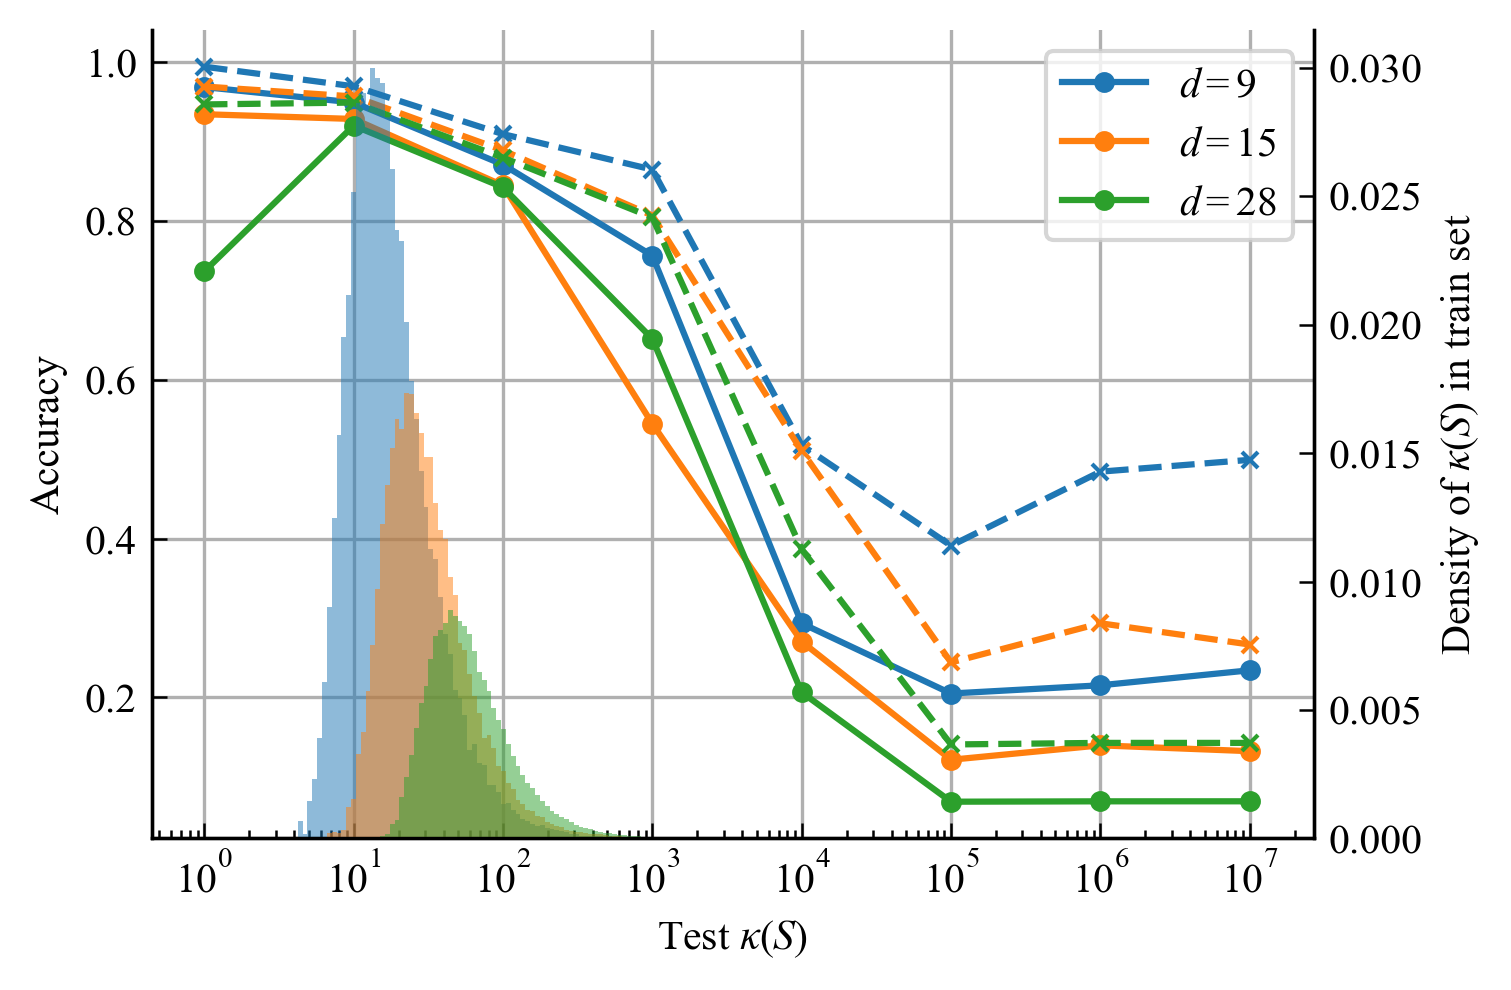

In [53]:
plot_model_results(results, kappas_distr, kappas=[1, 10, 100, 10**3, 10**4, 10**5, 10**6, 10**7])

In [56]:
results_reg = {}
for d in [9]:
    with open(f"sandbox/jordan8_kappa_results/results_{d}_reg.json", "r") as f:
        results_reg[d] = json.load(f)

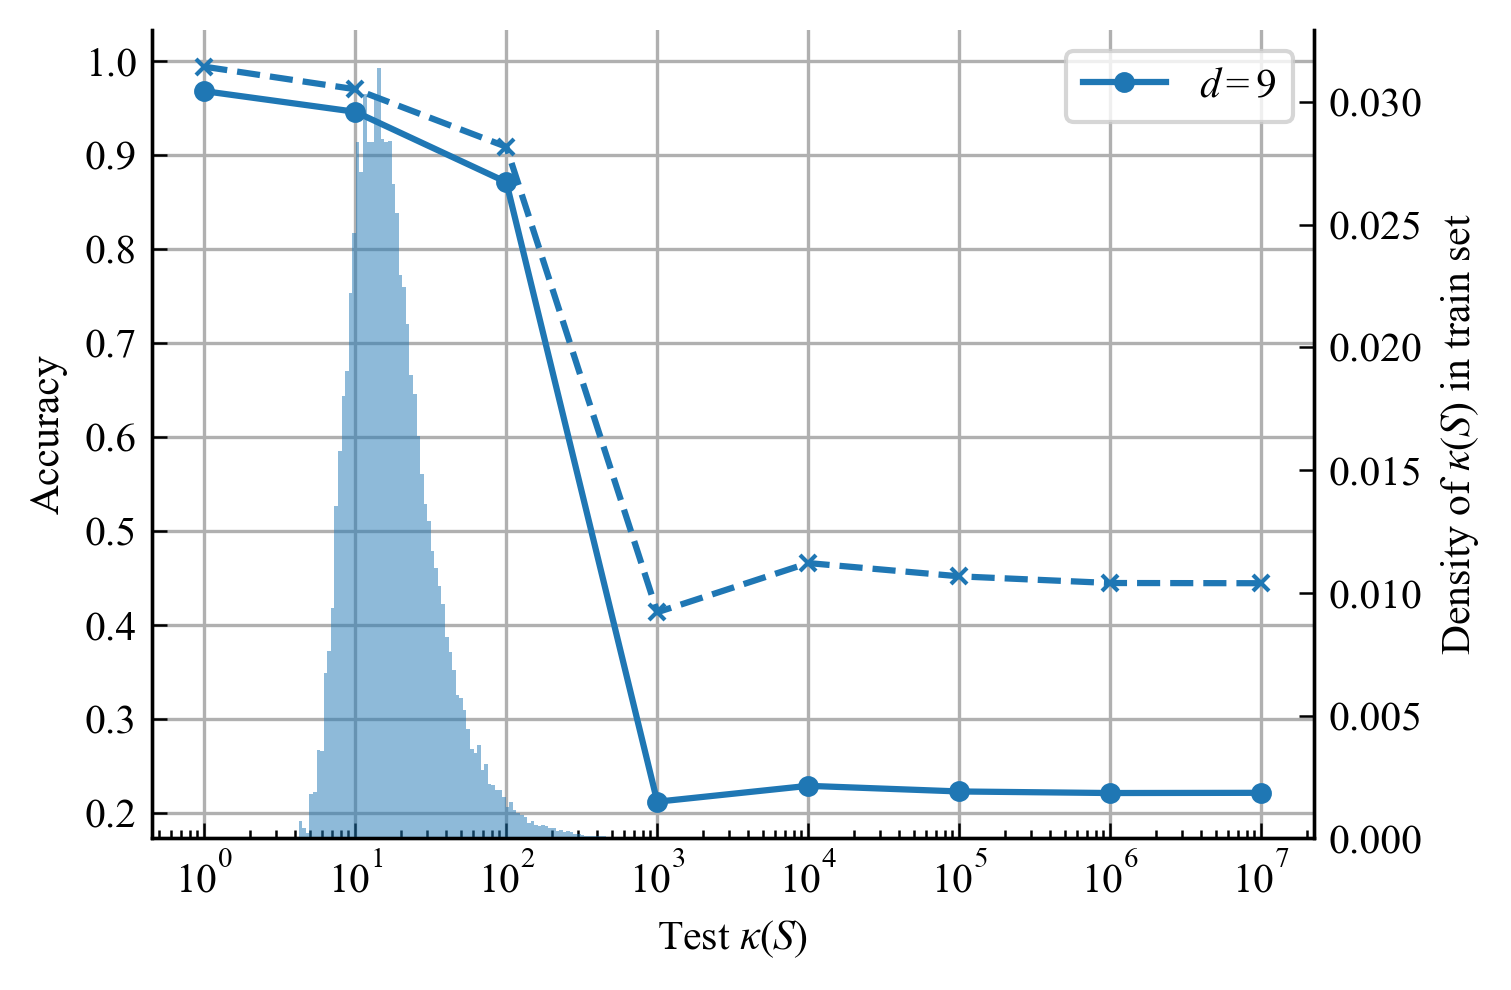

In [57]:
plot_model_results(results_reg, kappas_distr, ds=[9], kappas=[1, 10, 100, 10**3, 10**4, 10**5, 10**6, 10**7])